# Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

1. Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. 

1. Would you accept that coupon and take a short detour to the restaurant? 

1. Would you accept the coupon but use it on a subsequent trip? 

1. Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? 

1. What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? 

1. What about if it was just you and your partner in the car? 
    
1. Would weather impact the rate of acceptance? What about the time of day?

1. Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not,

    * but what are the factors that determine whether a driver accepts the coupon once it is delivered to them?

1.. How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. 
The survey describes different driving scenarios including the 
1. destination,
2. current time,
3. weather,
4. passenger, etc.,


1. and then ask the person whether he will accept the coupon if he is the driver.
2. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’
3. and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.

1. There are five different types of coupons --
   1. less expensive restaurants (under \$20),
   2. coffee houses,
   3. carry out & take away,
   4. bar, and
   5. more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  

To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. 

You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from plotly import express as px

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [2]:
data = pd.read_csv('data/coupons.csv')

In [3]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   destination           12684 non-null  str  
 1   passanger             12684 non-null  str  
 2   weather               12684 non-null  str  
 3   temperature           12684 non-null  int64
 4   time                  12684 non-null  str  
 5   coupon                12684 non-null  str  
 6   expiration            12684 non-null  str  
 7   gender                12684 non-null  str  
 8   age                   12684 non-null  str  
 9   maritalStatus         12684 non-null  str  
 10  has_children          12684 non-null  int64
 11  education             12684 non-null  str  
 12  occupation            12684 non-null  str  
 13  income                12684 non-null  str  
 14  car                   108 non-null    str  
 15  Bar                   12577 non-null  str  
 16  CoffeeHouse    

In [5]:
data.shape

(12684, 26)

# Checking for Nan values

In [6]:
data.isna().sum()

destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64

In [7]:
## Replace all Nans with ''. This problem is only in the Bar, CoffeeHouse, and CarrAway, RestaruantLessThan20 and Restaurant20To50

3. Decide what to do about your missing data -- drop, replace, other...

### Car

In [8]:
data['car'].unique()

<ArrowStringArray>
[                                       nan,
                   'Scooter and motorcycle',
                                'crossover',
                                   'Mazda5',
                             'do not drive',
 'Car that is too old to install Onstar :D']
Length: 6, dtype: str

In [9]:
data['car'][data['car'].isna()]

0        NaN
1        NaN
2        NaN
3        NaN
4        NaN
        ... 
12679    NaN
12680    NaN
12681    NaN
12682    NaN
12683    NaN
Name: car, Length: 12576, dtype: str

In [10]:
data['car'] = data['car'].fillna('')

### Bar

In [11]:
data['Bar'].unique()

<ArrowStringArray>
['never', 'less1', '1~3', 'gt8', nan, '4~8']
Length: 6, dtype: str

In [12]:
data['Bar'] = data['Bar'].fillna('')

In [13]:
data['CoffeeHouse'].unique()

<ArrowStringArray>
['never', 'less1', '4~8', '1~3', 'gt8', nan]
Length: 6, dtype: str

In [14]:
data['CoffeeHouse'] = data['CoffeeHouse'].fillna('')

In [15]:
data['CarryAway'].unique()

<ArrowStringArray>
[nan, '4~8', '1~3', 'gt8', 'less1', 'never']
Length: 6, dtype: str

In [16]:
data['CarryAway'] = data['CarryAway'].fillna('')

In [17]:
data['RestaurantLessThan20'].unique()

<ArrowStringArray>
['4~8', '1~3', 'less1', 'gt8', nan, 'never']
Length: 6, dtype: str

In [18]:
data['RestaurantLessThan20'] = data['RestaurantLessThan20'].fillna('')

In [19]:
data['Restaurant20To50'].unique()

<ArrowStringArray>
['1~3', 'less1', 'never', 'gt8', '4~8', nan]
Length: 6, dtype: str

In [20]:
data['Restaurant20To50'] = data['Restaurant20To50'].fillna('')
data['Restaurant20To50'].unique()

<ArrowStringArray>
['1~3', 'less1', 'never', 'gt8', '4~8', '']
Length: 6, dtype: str

In [21]:
data.isna().sum()

destination             0
passanger               0
weather                 0
temperature             0
time                    0
coupon                  0
expiration              0
gender                  0
age                     0
maritalStatus           0
has_children            0
education               0
occupation              0
income                  0
car                     0
Bar                     0
CoffeeHouse             0
CarryAway               0
RestaurantLessThan20    0
Restaurant20To50        0
toCoupon_GEQ5min        0
toCoupon_GEQ15min       0
toCoupon_GEQ25min       0
direction_same          0
direction_opp           0
Y                       0
dtype: int64

In [22]:
data.eq('').sum()

destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64

This is identical to the isna.sum() statent above, so all values have a value or they were Nan and have been set to ''

In [23]:
data.shape

(12684, 26)

In [24]:
len(data[data.duplicated() == True])

74

In [25]:
74/12684 * 100

0.5834121728161463

74 of the 12684 rows are duplicates. Its unclear if these are problems with the data or if the two individual of the same profile simply used the coupons are the same time. Given the time is a rough measure of time.. no minutes or seconds is it possible that two single females 21 years old used the coupons at the same time. And even if they are duplicates they represent 0.6 percent of the data, so we will keep them in.

Use both duplicate and dropped duplicaate to see if there is any difference

In [26]:
# data_deduped = data.drop_duplicates()

In [27]:
data.columns

Index(['destination', 'passanger', 'weather', 'temperature', 'time', 'coupon',
       'expiration', 'gender', 'age', 'maritalStatus', 'has_children',
       'education', 'occupation', 'income', 'car', 'Bar', 'CoffeeHouse',
       'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50',
       'toCoupon_GEQ5min', 'toCoupon_GEQ15min', 'toCoupon_GEQ25min',
       'direction_same', 'direction_opp', 'Y'],
      dtype='str')

In [28]:
data['time'].unique()

<ArrowStringArray>
['2PM', '10AM', '6PM', '7AM', '10PM']
Length: 5, dtype: str

In [29]:
data.loc[0]

destination                      No Urgent Place
passanger                                  Alone
weather                                    Sunny
temperature                                   55
time                                         2PM
coupon                           Restaurant(<20)
expiration                                    1d
gender                                    Female
age                                           21
maritalStatus                  Unmarried partner
has_children                                   1
education               Some college - no degree
occupation                            Unemployed
income                           $37500 - $49999
car                                             
Bar                                        never
CoffeeHouse                                never
CarryAway                                       
RestaurantLessThan20                         4~8
Restaurant20To50                             1~3
toCoupon_GEQ5min    

In [30]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,,4~8,1~3,1,1,0,0,1,0


4. What proportion of the total observations chose to accept the coupon?



In [31]:
data['Y'].unique()

array([1, 0])

In [32]:
len(data[data['Y'] == 1])

7210

In [33]:
len(data[data['Y'] == 1])/ len(data) * 100

56.84326710816777

57 percent of the observations accepted the coupon

5. Use a bar plot to visualize the `coupon` column.

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Restaurant(<20)'),
  Text(1, 0, 'Coffee House'),
  Text(2, 0, 'Carry out & Take away'),
  Text(3, 0, 'Bar'),
  Text(4, 0, 'Restaurant(20-50)')])

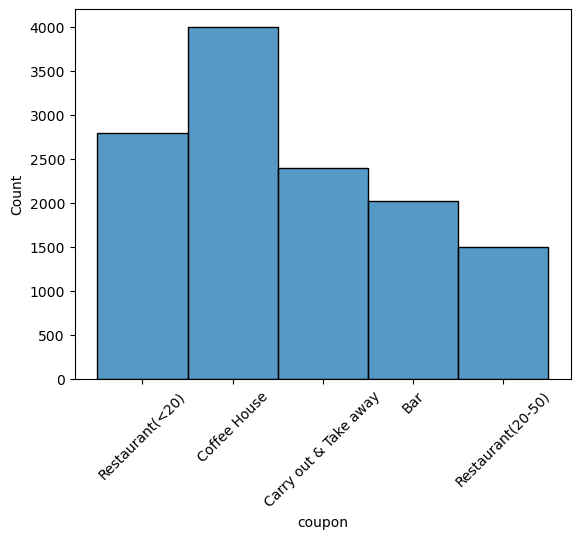

In [34]:
sns.histplot(data=data,x='coupon')
plt.xticks(rotation=45)

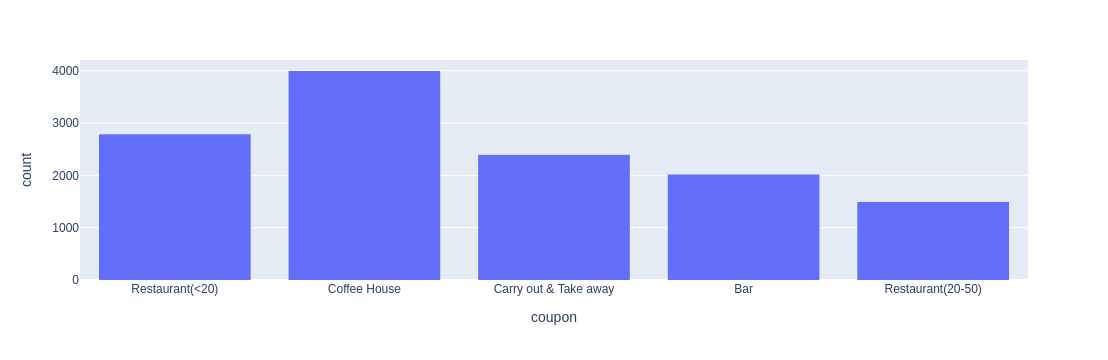

In [35]:
fig = px.histogram(data, x="coupon")                
fig.show()

6. Use a histogram to visualize the temperature column.

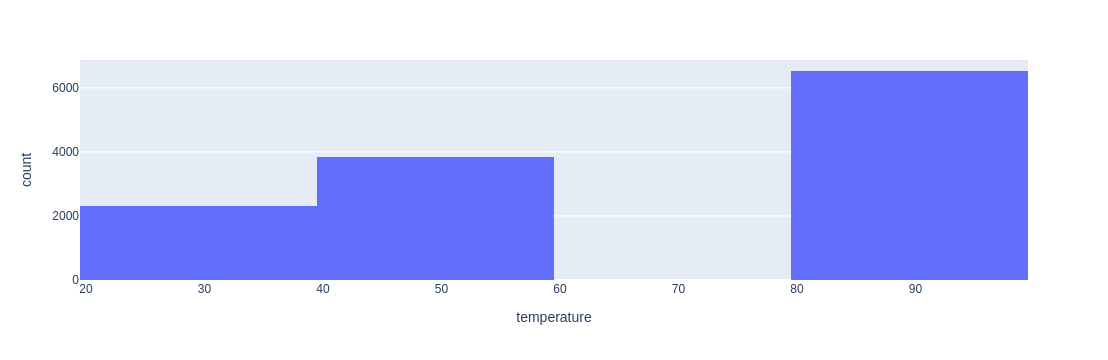

In [36]:
fig = px.histogram(data, x="temperature")                
fig.show()

(array([20., 30., 40., 50., 60., 70., 80., 90.]),
 [Text(20.0, 0, '20'),
  Text(30.0, 0, '30'),
  Text(40.0, 0, '40'),
  Text(50.0, 0, '50'),
  Text(60.0, 0, '60'),
  Text(70.0, 0, '70'),
  Text(80.0, 0, '80'),
  Text(90.0, 0, '90')])

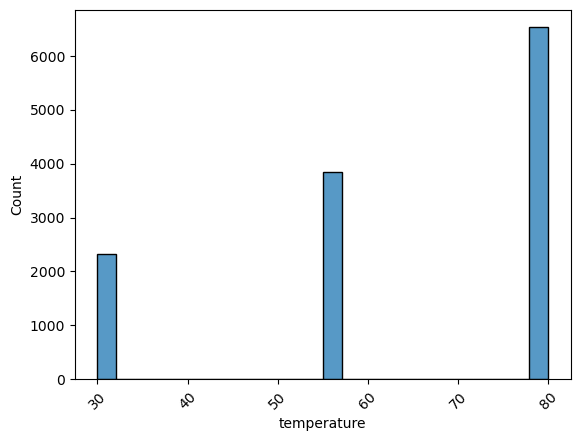

In [37]:
sns.histplot(data=data,x='temperature')
plt.xticks(rotation=45)

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [38]:
data['coupon'].unique()

<ArrowStringArray>
[      'Restaurant(<20)',          'Coffee House', 'Carry out & Take away',
                   'Bar',     'Restaurant(20-50)']
Length: 5, dtype: str

In [39]:
bardf = data[['Bar']]

2. What proportion of bar coupons were accepted?


In [40]:
bar_df = data[data['coupon'] == 'Bar']
len(bar_df)

2017

In [41]:
bar_yes = data[(data['Y'] == 1) & (data['coupon'] == 'Bar')]
len(bar_yes)

827

In [42]:
len(bar_yes)/len(bar_df)

0.41001487357461575

41 percent of individuals in the Bar used the coupon

3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [43]:
data['Bar'].unique()

<ArrowStringArray>
['never', 'less1', '1~3', 'gt8', '', '4~8']
Length: 6, dtype: str

In [44]:
yes_df = data[data['Y'] == 1]
len(yes_df)

7210

In [45]:
y_bar_lte3_df = yes_df[(yes_df['Bar'] == 'less1') | (yes_df['Bar'] == '1~3')]
y_bar_lte3 = len(y_bar_lte3_df)

In [46]:
y_bar_gt3_df = yes_df[ (yes_df['Bar'] == '4~8') | (yes_df['Bar'] == 'gt8')]
y_bar_gt3 = len(y_bar_gt3_df)
y_bar_gt3

887

In [47]:
y_bar_lte3 / y_bar_gt3

3.947012401352875

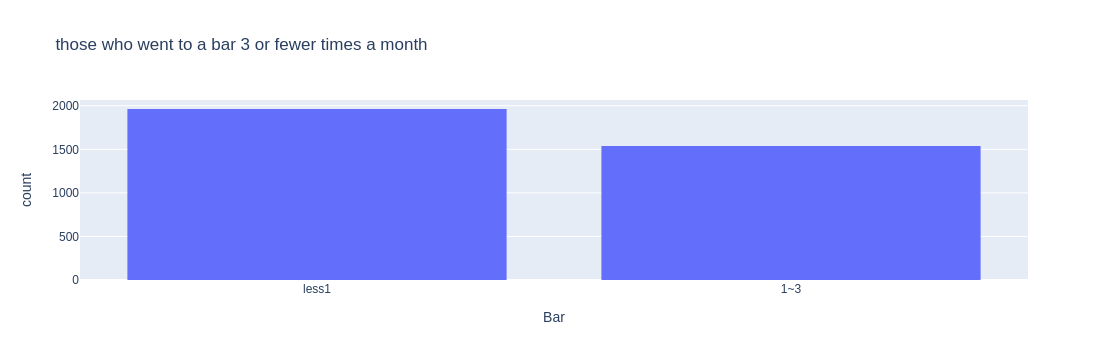

In [48]:

fig = px.histogram(y_bar_lte3_df, x="Bar",  title="those who went to a bar 3 or fewer times a month")
fig.show()

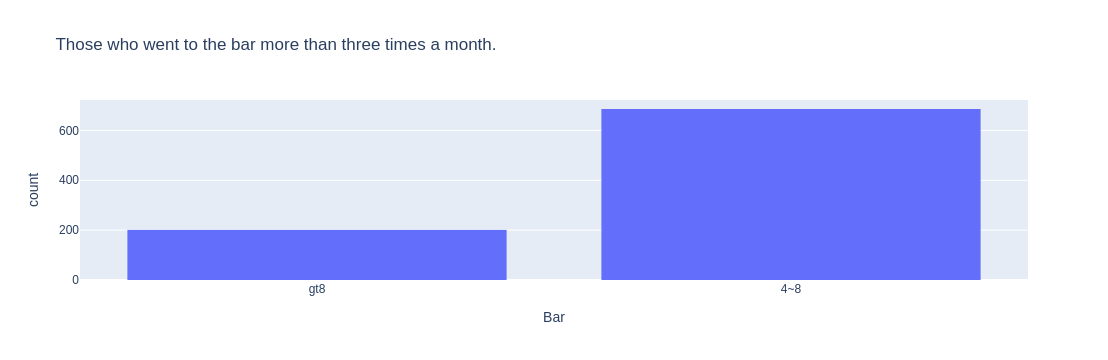

In [49]:
fig = px.histogram(y_bar_gt3_df, x="Bar", title="Those who went to the bar more than three times a month.")                
fig.show()


Those who went to the bar three or less times a month used the coupon nearly four times more than those who went to the bar greater than three times a month. Those who went to the bar three or less times a month were 3501. Those more than three were 887. The ration is 3501/887 == 3.947012401352875

4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


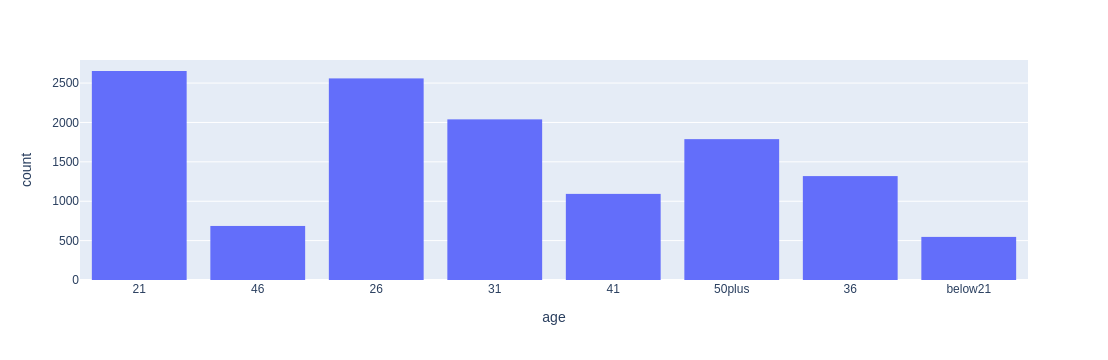

In [50]:
fig = px.histogram(data, x="age")                
fig.show()

In [51]:
morethan_1_month = data[ (data['Bar'] == '1~3') | (data['Bar'] == '4~8') | (data['Bar'] == 'gt8')]
morethan_1_month.head(1)

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
88,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Male,21,Single,...,less1,1~3,less1,1~3,1,0,0,0,1,0


In [52]:
morethan_1_month['age'].unique()

<ArrowStringArray>
['21', '26', '31', '50plus', '41', '36', '46', 'below21']
Length: 8, dtype: str

In [53]:
g1m_g25 = morethan_1_month[(morethan_1_month['age'] != '21') & (morethan_1_month['age'] != 'below21')]
g1m_g25['age'].unique()

<ArrowStringArray>
['26', '31', '50plus', '41', '36', '46']
Length: 6, dtype: str

In [54]:
len(g1m_g25) # greater than once a month. greater than 25 years old

2777

In [55]:
#g1m_g25['Y'] = g1m_g25['Y'].astype(int)

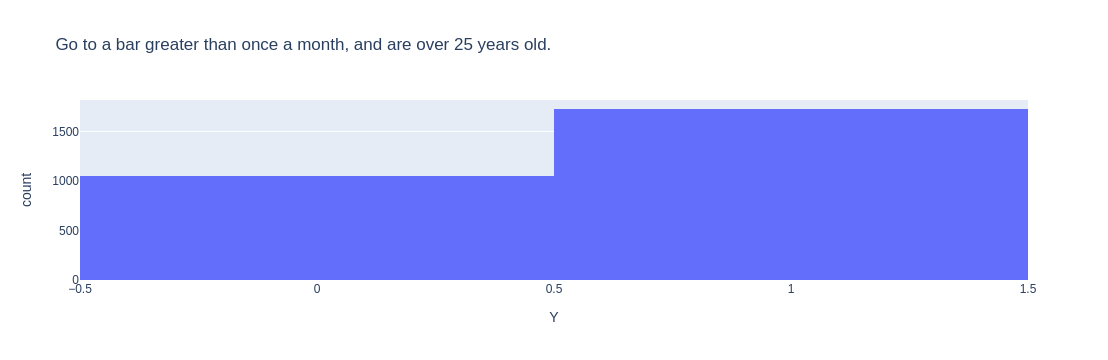

In [56]:
fig = px.histogram(g1m_g25, x="Y", title="Go to a bar greater than once a month, and are over 25 years old.")                
fig.show()

In [57]:
lesthan_1_month_df = data[ (data['Bar'] == 'less1')]
len(lesthan_1_month_df) # bar less than once a month)

3482

In [58]:
lt1m_lt25_df = lesthan_1_month_df[(lesthan_1_month_df['age'] == '21') | (lesthan_1_month_df['age'] == 'below21')]

In [59]:
lt1m_lt25_df ['Bar'].unique()

<ArrowStringArray>
['less1']
Length: 1, dtype: str

In [60]:
lt1m_lt25_df ['age'].unique()

<ArrowStringArray>
['21', 'below21']
Length: 2, dtype: str

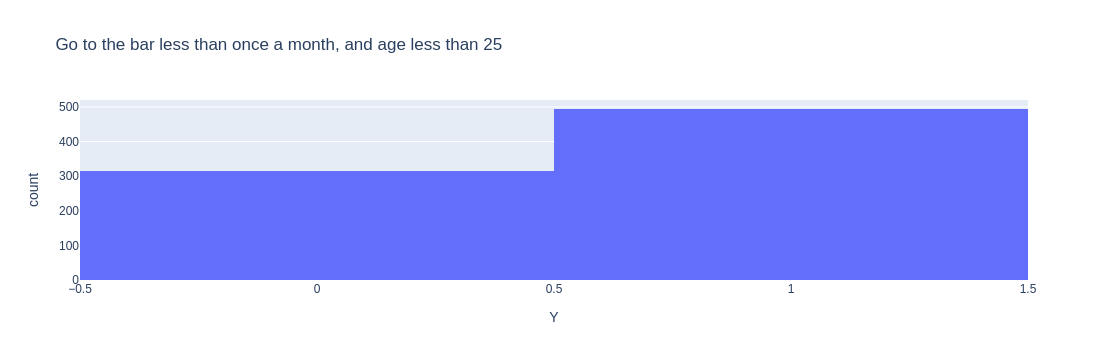

In [61]:
fig = px.histogram(lt1m_lt25_df, x="Y", title="Go to the bar less than once a month, and age less than 25" )                
fig.show()

In [62]:
len(g1m_g25[g1m_g25['Y'] == 1]) # go to the bar greater than once a month over 25 and use a coupon

1726

In [63]:
len(g1m_g25)

2777

In [64]:
len(lt1m_lt25_df[lt1m_lt25_df['Y'] == 1]) # go to the bar less than once a month, and under 25

494

In [65]:
len(lt1m_lt25_df)

808

In [66]:
808/2777

0.29096146921137916

In [67]:
2777/808

3.4368811881188117

In [68]:
1726/2777 # Percentage of those who go the bar more than once a month that use a coupon

0.6215340295282679

In [69]:
494/808 # Percentage of those who go to the bar less than once a month and are under 25

0.6113861386138614

Although there are 3.5 times as many customers who are over 25 and go to the bar more than once a month than those who are under 25 and go to the bar less than once a month, the percentage of those who use coupone is 62% and 61% respectively. So there does not seem to be a difference between these two groups.

#### 5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [172]:
morethan_1_monthdf = data[ (data['Bar'] == '1~3') | (data['Bar'] == '4~8') | (data['Bar'] == 'gt8')]
morethan_1_monthdf['Bar'].unique()

<ArrowStringArray>
['1~3', 'gt8', '4~8']
Length: 3, dtype: str

In [71]:
morethan_1_monthdf['passanger'].unique()

<ArrowStringArray>
['Alone', 'Friend(s)', 'Partner', 'Kid(s)']
Length: 4, dtype: str

In [173]:
g1m_pnk_df = morethan_1_monthdf[(morethan_1_monthdf["passanger"]!= "Kid(s)") & (morethan_1_monthdf["passanger"]!= "Alone")]

In [174]:
g1m_pnk_df['passanger'].unique()

<ArrowStringArray>
['Friend(s)', 'Partner']
Length: 2, dtype: str

In [175]:
morethan_1_monthdf["occupation"].unique() 
# There are no Farming Fishing or Forestry customers who come to the bar more than once a month.

<ArrowStringArray>
[                                  'Student',
                        'Healthcare Support',
                                'Management',
                                'Unemployed',
                           'Sales & Related',
           'Office & Administrative Support',
                 'Construction & Extraction',
                                     'Legal',
              'Life Physical Social Science',
                                   'Retired',
                   'Computer & Mathematical',
      'Healthcare Practitioners & Technical',
                   'Personal Care & Service',
                'Architecture & Engineering',
  'Arts Design Entertainment Sports & Media',
                        'Protective Service',
                      'Business & Financial',
        'Food Preparation & Serving Related',
         'Installation Maintenance & Repair',
                'Education&Training&Library',
               'Community & Social Services',
               

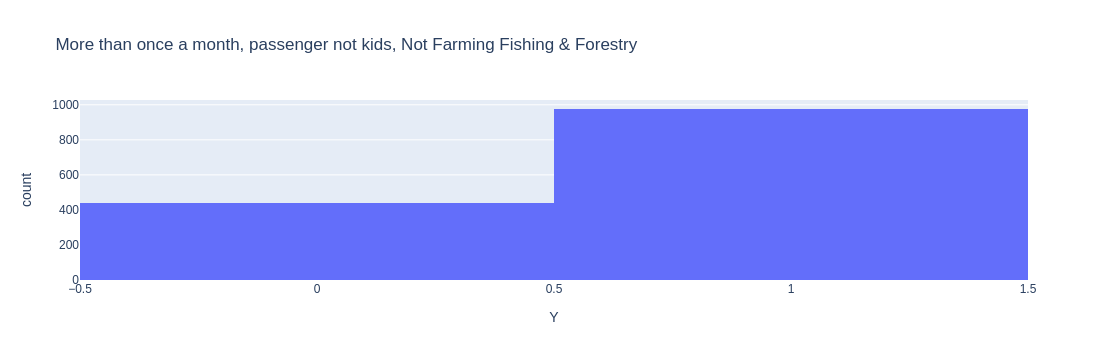

In [176]:
fig = px.histogram(g1m_pnk_df, x="Y",title="More than once a month, passenger not kids, Not Farming Fishing & Forestry")
fig.show()

In [177]:
glm_pnk_len = len(g1m_pnk_df) # all who go to the bar more than once a month, passengers are not kids

In [178]:
g1m_pnk_Y_len = len(g1m_pnk_df[g1m_pnk_df['Y'] == 1])
g1m_pnk_Y_len

976

In [179]:
g1m_pnk_Y_len/glm_pnk_len

0.6902404526166902

Sixty-nine percent of the population who go more than once a month, have passengers that are not kids, and are not farming, fishing or forestry chose to use coupons. There are no Farming, Fishing nor Forestry people among those who come to the bar greater than once a month and have customers that are not kids, so this is not relevant.

6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [ ]:
data.columns

In [91]:
g1m_pnk_df['Bar'].unique()

<ArrowStringArray>
['1~3', 'gt8', '4~8']
Length: 3, dtype: str

In [92]:
g1m_pnk_df['passanger'].unique()

<ArrowStringArray>
['Friend(s)', 'Partner']
Length: 2, dtype: str

In [94]:
g1m_pnk_df['maritalStatus'].unique()

<ArrowStringArray>
['Single', 'Unmarried partner', 'Married partner', 'Divorced']
Length: 4, dtype: str

#### greater than once a month with non kid passangeres are not widowed.

In [95]:
morethan_1_month = data[ (data['Bar'] == '1~3') | (data['Bar'] == '4~8') | (data['Bar'] == 'gt8')]
morethan_1_month['Bar'].unique()

<ArrowStringArray>
['1~3', 'gt8', '4~8']
Length: 3, dtype: str

In [99]:
morethan_1_month['age'].unique()

<ArrowStringArray>
['21', '26', '31', '50plus', '41', '36', '46', 'below21']
Length: 8, dtype: str

In [104]:
m1m_lt30_df = morethan_1_month[morethan_1_month['age'].isin(["26", "21", "below21"])]
m1m_lt30_df['age'].unique()

<ArrowStringArray>
['21', '26', 'below21']
Length: 3, dtype: str

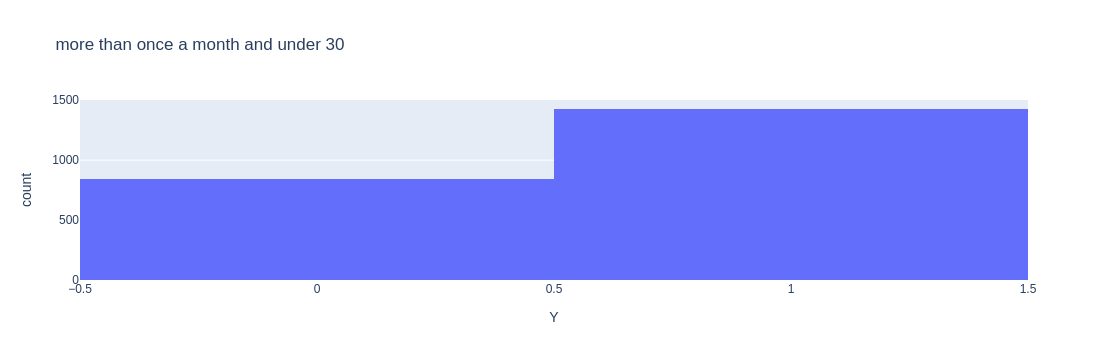

In [105]:
fig = px.histogram(m1m_lt30_df, x="Y", title="more than once a month and under 30")                
fig.show()

In [106]:
m1m_lt30_len = len(m1m_lt30_df)
m1m_lt30_len

2272

In [113]:
m1m_lt30_Y_df = m1m_lt30_df[m1m_lt30_df['Y'] == 1]
mlm_lt30_Y_len = len(m1m_lt30_Y_df)
mlm_lt30_Y_len

1427

In [114]:
mlm_lt30_Y_len/m1m_lt30_len

0.628080985915493

Sixty-two of customers who go to the bar more than once a month, and are under 30 use the coupons

In [ ]:
#go to cheap restaurants more than 4 times a month and income is less than 50K.

In [ ]:
data.columns

In [120]:
crg4_df = data[data['RestaurantLessThan20'].isin(["4~8","gt8"])]
crg4_df["income"].unique()

<ArrowStringArray>
[ '$37500 - $49999',  '$62500 - $74999',  '$100000 or More',
  '$50000 - $62499',  '$25000 - $37499',  '$75000 - $87499',
  '$87500 - $99999',  '$12500 - $24999', 'Less than $12500']
Length: 9, dtype: str

In [121]:
crg4_il50K_df = crg4_df[crg4_df["income"].isin(["$37500 - $49999","$25000 - $37499"])]

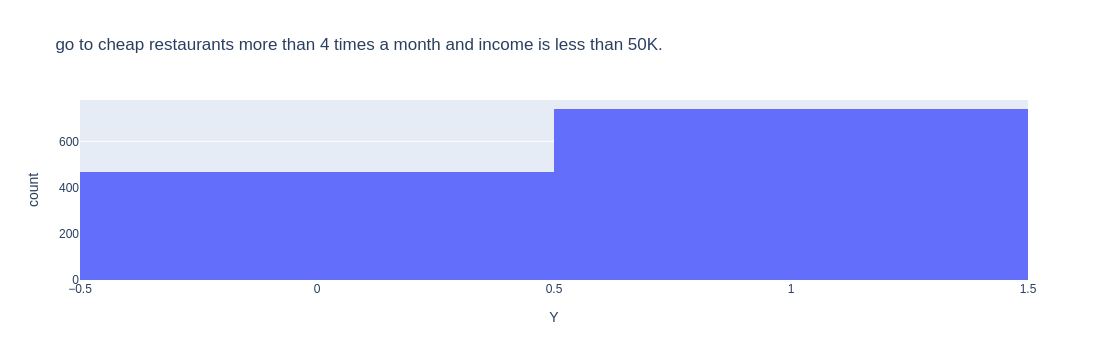

In [122]:
fig = px.histogram(crg4_il50K_df, x="Y", title="go to cheap restaurants more than 4 times a month and income is less than 50K.")                
fig.show()

In [126]:
crg4_il50K_len = len(crg4_il50K_df)
crg4_il50K_len

1208

In [127]:
crg4_il50K_Y_df = crg4_il50K_df[crg4_il50K_df["Y"] == 1]
crg4_il50K_Y_len = len(crg4_il50K_Y_df)
crg4_il50K_Y_len

740

In [128]:
crg4_il50K_Y_len/crg4_il50K_len

0.6125827814569537

#### Sixty-one percent of customers who do to less than 20 dollar restaurants, more than 4 times a month, and make less than 50K use coupons.

7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

Sixty-nine percent of the population who go more than once a month, have passengers that are not kids chose to use coupons. There are no Farming, Passengers with no kids were Friends are a partner.  Frequency and coming with other increase the chances. 

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

### Expensive Restaurant

In [190]:
rest_20to50_df = data[data['Restaurant20To50'] == 'gt8']

In [187]:
def yes_coupon(df):
    return df[df['Y'] == 1]

In [191]:
rest_20to50_Y_df = yes_coupon(rest_20to50_df)

In [192]:
def ratio(df1,df2):
    return len(df1)/len(df2)

In [193]:
ratio(rest_20to50_Y_df,rest_20to50_df)

0.6628787878787878

In [216]:
data['age'].unique()

<ArrowStringArray>
['21', '46', '26', '31', '41', '50plus', '36', 'below21']
Length: 8, dtype: str

In [201]:
rest_20to50_kids_df = rest_20to50_df[rest_20to50_df["passanger"] == 'Kid(s)']
rest_20to50_kids_Y_df = yes_coupon(rest_20to50_kids_df)
ratio(rest_20to50_kids_Y_df,rest_20to50_kids_df)

0.5454545454545454

In [204]:
rest_20to50_kids_df = rest_20to50_df[rest_20to50_df["passanger"].isin(["Friend(s)"])] # 69% with Friends
rest_20to50_kids_Y_df = yes_coupon(rest_20to50_kids_df)
ratio(rest_20to50_kids_Y_df,rest_20to50_kids_df)

0.6923076923076923

In [205]:
rest_20to50_kids_df = rest_20to50_df[rest_20to50_df["passanger"].isin(["Partner"])]
rest_20to50_kids_Y_df = yes_coupon(rest_20to50_kids_df)
ratio(rest_20to50_kids_Y_df,rest_20to50_kids_df)

0.625

In [206]:
rest_20to50_kids_df = rest_20to50_df[rest_20to50_df["passanger"].isin(["Alone"])]
rest_20to50_kids_Y_df = yes_coupon(rest_20to50_kids_df)
ratio(rest_20to50_kids_Y_df,rest_20to50_kids_df)

0.6558441558441559

In [202]:
data["passanger"].unique()

<ArrowStringArray>
['Alone', 'Friend(s)', 'Kid(s)', 'Partner']
Length: 4, dtype: str

In [214]:
fifty_plus_df = data[data['age'] == '50plus']
fifty_plus_Y_df = yes_coupon(fifty_plus_df)
ratio(fifty_plus_Y_df, fifty_plus_df)

0.5089485458612976

In [215]:
fifty_plus_friends_df = fifty_plus_df[fifty_plus_df["passanger"].isin(["Friend(s)"])] # having friends increases by 9 percent!
fifty_plus_friends_Y_df = yes_coupon(fifty_plus_friends_df)
ratio(fifty_plus_friends_Y_df,fifty_plus_friends_df)

0.5919661733615222

In [218]:
twenty_one_df = data[data['age'].isin(["21"])]
twenty_one_Y_df = yes_coupon(twenty_one_df)
ratio(twenty_one_Y_df, twenty_one_df)

0.5981907274783265

In [221]:
twenty_one_friends_df = twenty_one_df[twenty_one_df["passanger"].isin(["Friend(s)"])] # having friends increases by 10 percent!
twenty_one_friends_Y_df = yes_coupon(twenty_one_friends_df)
ratio(twenty_one_friends_Y_df,twenty_one_friends_df)

0.6970108695652174

In [222]:
twenty_one_friends_df = twenty_one_df[twenty_one_df["passanger"].isin(["Friend(s)"])] # having friends increases by 10 percent!
twenty_one_friends_Y_df = yes_coupon(twenty_one_friends_df)
ratio(twenty_one_friends_Y_df,twenty_one_friends_df)

0.6970108695652174

In [223]:
young_df = data[data['age'].isin(["21", "26", "31"])]
young_Y_df = yes_coupon(young_df)
ratio(young_Y_df, young_df)

0.5828161632878224

In [229]:
young_friends_df = young_df[young_df["passanger"].isin(["Friend(s)"])] # having friends increases by 11 percent!
young_friends_Y_df = yes_coupon(young_friends_df)
ratio(young_friends_Y_df,young_friends_df)

0.6988457502623295

In [265]:
data['CoffeeHouse'].unique()

<ArrowStringArray>
['never', 'less1', '4~8', '1~3', 'gt8', '']
Length: 6, dtype: str

## Coffee House

In [272]:
ch_df = data[data['CoffeeHouse'].isin(['gt8'])]
ch_Y_df = yes_coupon(ch_df)
ratio(ch_Y_df, ch_df)

0.5832583258325833

In [273]:
ch_wc_df = ch_df[ch_df['has_children'] == 1]
ch_wc_Y_df = yes_coupon(ch_wc_df)
ratio(ch_wc_Y_df, ch_wc_df)

0.5503875968992248

In [274]:
ch_wc_7_df = ch_wc_df[ch_wc_df['time'] == '7AM']
ch_wc_7_Y_df = yes_coupon(ch_wc_7_df)
ratio(ch_wc_7_Y_df, ch_wc_7_df)

0.488

In [269]:
ch_wc_7_df = ch_wc_df[ch_wc_df['time'] == '10PM']
ch_wc_7_Y_df = yes_coupon(ch_wc_7_df)
ratio(ch_wc_7_Y_df, ch_wc_7_df)

0.49137931034482757

In [275]:
ch_wc_7_df = ch_wc_df[ch_wc_df['time'] == '6PM'] # time of day matters
ch_wc_7_Y_df = yes_coupon(ch_wc_7_df)
ratio(ch_wc_7_Y_df, ch_wc_7_df)

0.6062992125984252

In [276]:
ch_wc_7_df = ch_wc_df[ch_wc_df['time'] == '2PM'] # time of day matters 2PM!
ch_wc_7_Y_df = yes_coupon(ch_wc_7_df)
ratio(ch_wc_7_Y_df, ch_wc_7_df)

0.7093023255813954

Young Coffee Goers

In [277]:
young_df = data[data['age'].isin(["21", "26", "31"])]
young_Y_df = yes_coupon(young_df)
ratio(young_Y_df, young_df)

0.5828161632878224

In [282]:
young_ch_df = young_df[young_df['CoffeeHouse'].isin(['gt8'])]
young_ch_Y_df = yes_coupon(young_ch_df)
ratio(young_ch_Y_df, young_ch_df)

0.6185243328100472

In [283]:
young_friends_ch_df = young_ch_df[young_ch_df["passanger"].isin(["Friend(s)"])] # having friends increases by 11 percent!
young_friends_ch_Y_df = yes_coupon(young_friends_ch_df)
ratio(young_friends_ch_Y_df,young_friends_ch_df)

0.6763005780346821

In [284]:
ch_wc_7_df = young_friends_ch_df[young_friends_ch_df['time'] == '2PM'] # time of day matters!!
ch_wc_7_Y_df = yes_coupon(ch_wc_7_df)
ch_wc_7_Y_df
ratio(ch_wc_7_Y_df, ch_wc_7_df)

0.7727272727272727

In [242]:
ch_wc_df['income'].unique()

<ArrowStringArray>
[ '$12500 - $24999',  '$50000 - $62499',  '$25000 - $37499',
  '$100000 or More',  '$87500 - $99999',  '$75000 - $87499',
  '$37500 - $49999', 'Less than $12500']
Length: 8, dtype: str

In [235]:
data['time'].unique()

<ArrowStringArray>
['2PM', '10AM', '6PM', '7AM', '10PM']
Length: 5, dtype: str

# Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

1. Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. 

1. Would you accept that coupon and take a short detour to the restaurant? 

1. Would you accept the coupon but use it on a subsequent trip? 

1. Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? 

1. What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? 

1. What about if it was just you and your partner in the car? 
    
1. Would weather impact the rate of acceptance? What about the time of day?

1. Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not,

    * but what are the factors that determine whether a driver accepts the coupon once it is delivered to them?

1.. How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. 
The survey describes different driving scenarios including the 
1. destination,
2. current time,
3. weather,
4. passenger, etc.,


1. and then ask the person whether he will accept the coupon if he is the driver.
2. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’
3. and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.

1. There are five different types of coupons --
   1. less expensive restaurants (under \$20),
   2. coffee houses,
   3. carry out & take away,
   4. bar, and
   5. more expensive restaurants (\$20 - $50).

In [232]:
data.columns

Index(['destination', 'passanger', 'weather', 'temperature', 'time', 'coupon',
       'expiration', 'gender', 'age', 'maritalStatus', 'has_children',
       'education', 'occupation', 'income', 'car', 'Bar', 'CoffeeHouse',
       'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50',
       'toCoupon_GEQ5min', 'toCoupon_GEQ15min', 'toCoupon_GEQ25min',
       'direction_same', 'direction_opp', 'Y'],
      dtype='str')